In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [16]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/arnobbhowmik/ton-iot-network-dataset/train_test_network.csv')

df = df.drop_duplicates()

print("--- Data Types and Memory Usage ---")
df.info()

print("\n--- Statistical Summary of Numeric Columns ---")
display(df.describe())

print("\n--- Missing Values Check ---")
missing_vals = df.isnull().sum()
display(missing_vals[missing_vals > 0])

print("\n--- Attack Type Distribution (Multiclass) ---")
display(df['type'].value_counts())

print("\n--- Binary Label Distribution (0: Normal, 1: Attack) ---")
display(df['label'].value_counts())

--- Data Types and Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
Index: 190474 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  190474 non-null  object 
 1   src_port                190474 non-null  int64  
 2   dst_ip                  190474 non-null  object 
 3   dst_port                190474 non-null  int64  
 4   proto                   190474 non-null  object 
 5   service                 190474 non-null  object 
 6   duration                190474 non-null  float64
 7   src_bytes               190474 non-null  int64  
 8   dst_bytes               190474 non-null  int64  
 9   conn_state              190474 non-null  object 
 10  missed_bytes            190474 non-null  int64  
 11  src_pkts                190474 non-null  int64  
 12  src_ip_bytes            190474 non-null  int64  
 13  dst_pkts                190474 non-null  in

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,190474.000000,190474.000000,190474.000000,1.904740e+05,1.904740e+05,1.904740e+05,190474.000000,1.904740e+05,190474.000000,1.904740e+05,190474.000000,190474.000000,190474.000000,190474.000000,1.904740e+05,190474.000000,190474.000000
mean,39755.028098,2136.147989,8.532477,2.859868e+05,2.867525e+05,3.815064e+04,10.559882,8.480142e+02,4.248890,1.755264e+03,251.518585,3.923071,0.137378,0.072482,1.605803e+02,0.336723,0.779287
std,18808.989174,6971.550976,593.815814,1.799405e+07,1.897376e+07,5.538425e+06,96.557801,2.346881e+04,348.102025,2.001842e+05,2858.889139,24.959591,0.628847,9.729679,3.207557e+04,8.704852,0.414728
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,35650.000000,53.000000,0.000009,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,45729.500000,80.000000,0.000391,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.040000e+02,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,52042.750000,445.000000,0.136369,1.300000e+02,1.780000e+02,0.000000e+00,5.000000,4.230000e+02,2.000000,2.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000



--- Missing Values Check ---


Series([], dtype: int64)


--- Attack Type Distribution (Multiclass) ---


type
normal        42040
scanning      20000
ddos          19993
injection     19964
password      19861
dos           18992
backdoor      18711
xss           15137
ransomware    14735
mitm           1041
Name: count, dtype: int64


--- Binary Label Distribution (0: Normal, 1: Attack) ---


label
1    148434
0     42040
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

leakage_cols = ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'label']
columns_to_drop = [col for col in leakage_cols if col in df.columns]

X = df.drop(columns=columns_to_drop)

le_type = LabelEncoder()
y = le_type.fit_transform(X['type'])
X = X.drop(columns=['type'])

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X[col] = X[col].fillna('None').astype(str)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = X[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = X_scaled.astype(np.float32)

In [18]:
X_train_full, X_test_full, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
X_train_final = np.expand_dims(X_train_full, axis=2)
X_test_final = np.expand_dims(X_test_full, axis=2)
num_classes = len(np.unique(y_train))

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        cross_entropy = -y_true_one_hot * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1.0 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return focal_loss_fixed

model = Sequential([
    Conv1D(filters=64, kernel_size=3, input_shape=(X_train_final.shape[1], 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=32, kernel_size=3),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_ids_model_multi.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

history = model.fit(
    X_train_final, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_test_final, y_test),
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6458 - loss: 0.1736 - val_accuracy: 0.7402 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 2/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7430 - loss: 0.0864 - val_accuracy: 0.6927 - val_loss: 0.0849 - learning_rate: 0.0010
Epoch 3/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7571 - loss: 0.0787 - val_accuracy: 0.6314 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 4/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7693 - loss: 0.0738 - val_accuracy: 0.7234 - val_loss: 0.0891 - learning_rate: 0.0010
Epoch 5/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7851 - loss: 0.0695 - val_accuracy: 0.6300 - val_loss: 0.1670 - learning_rate: 5.0000e-04
Epoch 6/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7962 - loss: 0.0669 - val_accuracy: 0.7196 - val_loss: 0.0858 - learning_rate: 5.0000e-04
Epoch 7/50
596/596 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8068 

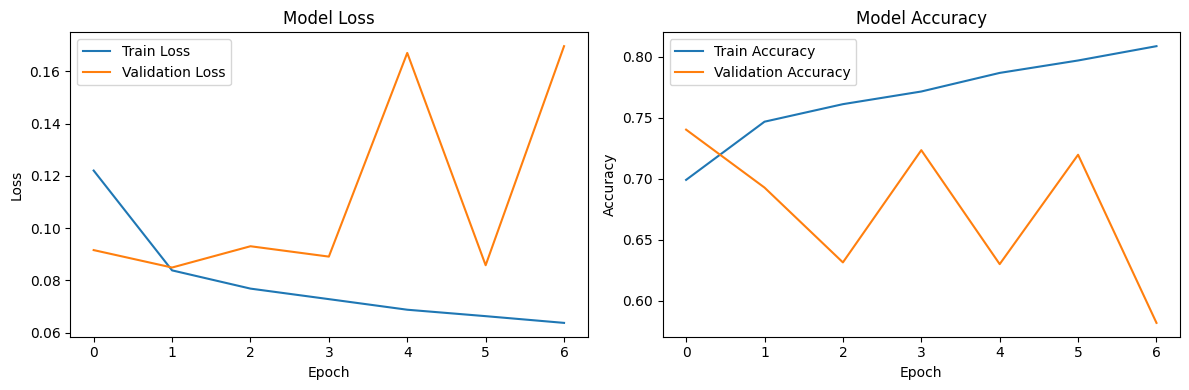

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

    backdoor       1.00      0.01      0.01      3714
        ddos       0.98      0.91      0.94      3993
         dos       0.38      0.91      0.54      3756
   injection       0.59      0.92      0.72      4078
        mitm       0.57      0.50      0.53       210
      normal       0.96      0.98      0.97      8389
    password       0.91      0.20      0.32      3948
  ransomware       0.98      0.22      0.36      2944
    scanning       0.87      0.78      0.82      4072
         xss       0.52      0.90      0.66      2991

    accuracy                           0.69     38095
   macro avg       0.78      0.63      0.59     38095
weighted avg       0.82      0.69      0.65     38095



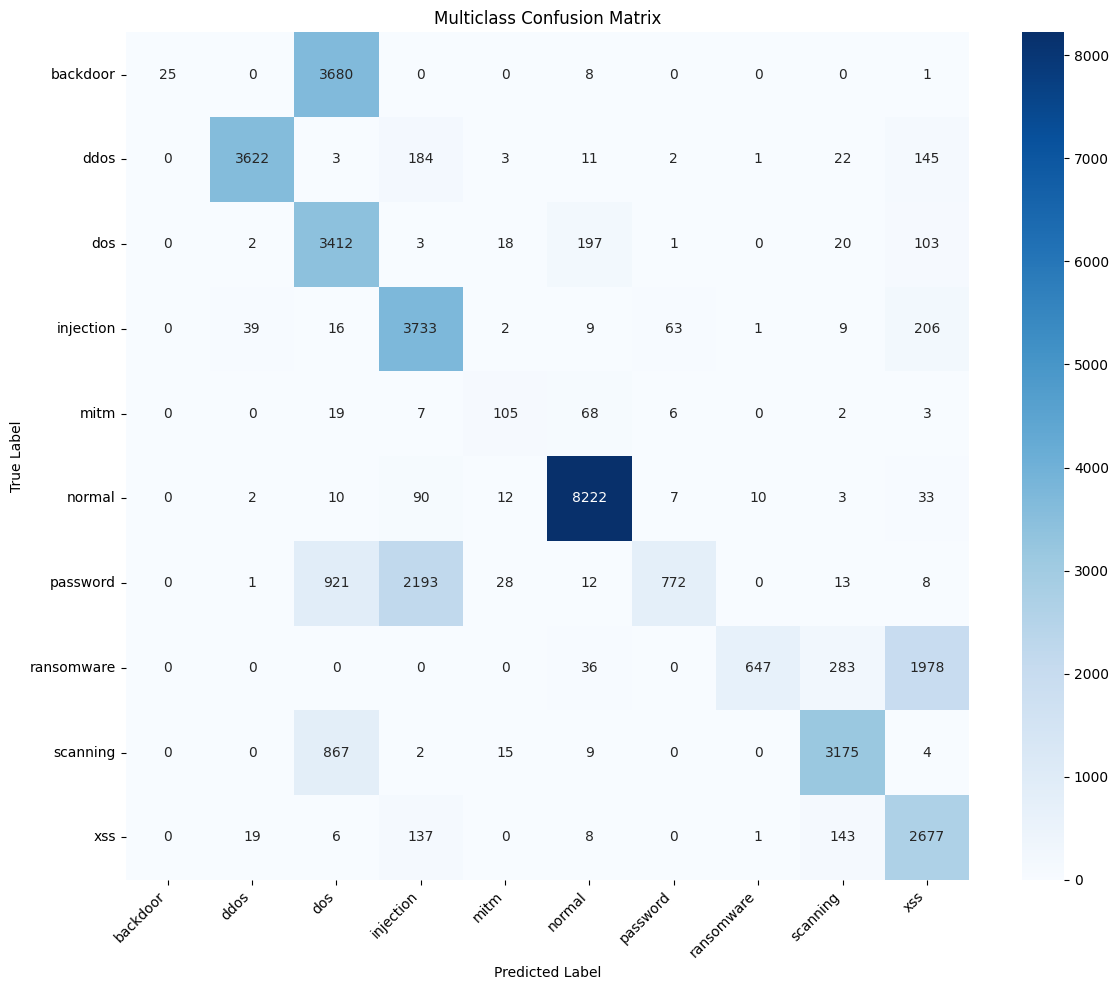

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = le_type.classes_

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

DNN 

In [22]:
tf.keras.backend.clear_session()

dnn_model = Sequential([
    Dense(256, input_shape=(X_train_full.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

dnn_model.compile(
    optimizer='adam', 
    loss=categorical_focal_loss(gamma=2.0, alpha=0.25), 
    metrics=['accuracy']
)

dnn_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
dnn_checkpoint = ModelCheckpoint('best_ids_model_dnn.keras', monitor='val_loss', save_best_only=True)
dnn_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

dnn_history = dnn_model.fit(
    X_train_full, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_test_full, y_test),
    callbacks=[dnn_early_stop, dnn_checkpoint, dnn_reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5874 - loss: 0.2026 - val_accuracy: 0.7328 - val_loss: 0.0805 - learning_rate: 0.0010
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7097 - loss: 0.0893 - val_accuracy: 0.7329 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7172 - loss: 0.0838 - val_accuracy: 0.7348 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7209 - loss: 0.0819 - val_accuracy: 0.7336 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7240 - loss: 0.0793 - val_accuracy: 0.7338 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7227 - loss: 0.0787 - val_accuracy: 0.7341 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7268 - loss: 

In [23]:
dnn_y_pred_probs = dnn_model.predict(X_test_full)
dnn_y_pred = np.argmax(dnn_y_pred_probs, axis=1)

print("--- DNN Classification Report ---")
print(classification_report(y_test, dnn_y_pred, target_names=target_names))

1191/1191 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
--- DNN Classification Report ---
              precision    recall  f1-score   support

    backdoor       0.44      1.00      0.61      3714
        ddos       0.98      0.91      0.94      3993
         dos       0.88      0.10      0.17      3756
   injection       0.54      0.91      0.68      4078
        mitm       0.58      0.73      0.65       210
      normal       0.97      0.98      0.98      8389
    password       1.00      0.06      0.11      3948
  ransomware       0.94      0.81      0.87      2944
    scanning       0.81      0.80      0.80      4072
         xss       0.76      0.82      0.79      2991

    accuracy                           0.74     38095
   macro avg       0.79      0.71      0.66     38095
weighted avg       0.83      0.74      0.69     38095

